## Objective
Now let’s focus on building a <b>Classification model</b> using a real dataset, the <b>Titanic data set</b>. There are <b>627 sample cases in the training dataset</b> and <b>264 cases in test dataset</b>. <b>10 attributes</b> have been assigned to each passenger.

We will use a Tensor Flow estimator to build a linear regression model.

<b>The objective of the study is to predict the passengers, who survived the tragedy, given characteristics such as gender, age, class, etc.</b>

## Import Libraries and Load data

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
train_x = pd.read_csv('/content/Namit Kumar - train - Namit Kumar - train.csv')
eval_x = pd.read_csv('/content/Namit Kumar - eval - Namit Kumar - eval.csv')
train_y = train_x.pop('survived')
eval_y = eval_x.pop('survived')

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Explore Data

In [3]:
# List the features in the dataset
train_x.head()



,sex,age,n_siblings_spouses,parch,fare,class,deck,embark_town,alone
0,male,22.0,1,0,7.2500,Third,unknown,Southampton,n
1,female,38.0,1,0,71.2833,First,C,Cherbourg,n
2,female,26.0,0,0,7.9250,Third,unknown,Southampton,y
3,female,35.0,1,0,53.1000,First,C,Southampton,n
4,male,28.0,0,0,8.4583,Third,unknown,Queenstown,y


In [7]:
train_x.dtypes

,0
sex,object
age,float64
n_siblings_spouses,int64
parch,int64
fare,float64
class,object
deck,object
embark_town,object
alone,object


In [4]:
# Statistical Analysis of the data
train_x.describe()


,age,n_siblings_spouses,parch,fare
count,627.000000,627.000000,627.000000,627.000000
mean,29.631308,0.545455,0.379585,34.385399
std,12.511818,1.151090,0.792999,54.597730
min,0.750000,0.000000,0.000000,0.000000
25%,23.000000,0.000000,0.000000,7.895800
50%,28.000000,0.000000,0.000000,15.045800
75%,35.000000,1.000000,0.000000,31.387500
max,80.000000,8.000000,5.000000,512.329200


In [8]:
# Number of records in each dataset
train_x.shape[0], eval_x.shape[0]

(627, 264)

<Axes: >

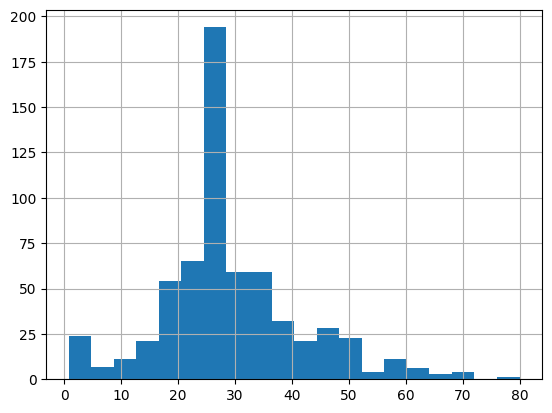

In [9]:
# Age distribution of the passengers
train_x['age'].hist(bins=20)


The majority of the passengers are in age group 20 and 30

<Axes: ylabel='sex'>

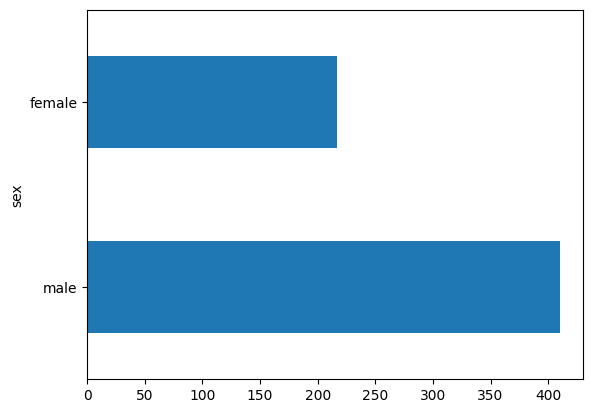

In [10]:
# Gender distribution of the passengers
train_x['sex'].value_counts().plot(kind='barh')


Males are more than double than females

<Axes: ylabel='class'>

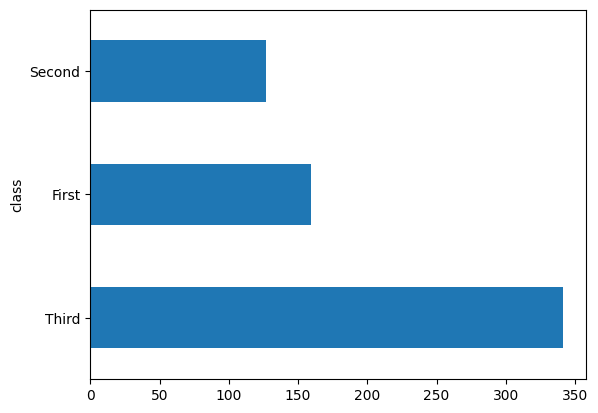

In [11]:
# Distribution by class
train_x['class'].value_counts().plot(kind='barh')


The maximum number of passengers were in the third class

<Axes: ylabel='sex'>

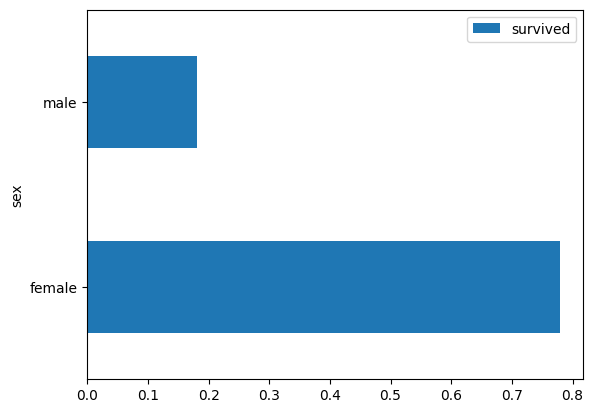

In [15]:
# Analyze the survival chances by sex
combined_df = pd.concat([train_x, train_y], axis=1)
combined_df[['sex', 'survived']].groupby(['sex']).mean().plot(kind='barh')

Survival chances for females are more than that of males

## Feature Column and Input Function

In [16]:
# Feature Column
CATEGORICAL_COLUMNS = ['sex', 'n_siblings_spouses', 'parch', 'class', 'deck', 'embark_town', 'alone']
NUMERIC_COLUMNS = ['age', 'fare']

feature_columns = []
for feature_name in CATEGORICAL_COLUMNS:
  # Vocabulary list is not provided in dataset, so for a simple solution I am keeping the bucket size as 10
  feature_columns.append(tf.feature_column.categorical_column_with_vocabulary_list(feature_name, vocabulary_list=train_x[feature_name].unique()))

for feature_name in NUMERIC_COLUMNS:
  feature_columns.append(tf.feature_column.numeric_column(feature_name, dtype=tf.float32))

Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.
Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.


In [22]:
# Input Function
def make_input_fn(data_df, label_df, num_epochs=10, shuffle=True, batch_size=32):
  def input_function():
    # Use a dictionary for features as expected by Estimators
    ds = tf.data.Dataset.from_tensor_slices((dict(data_df), label_df))
    if shuffle:
      ds = ds.shuffle(1000)
    ds = ds.repeat(num_epochs).batch(batch_size)
    return ds
  return input_function

The input_function converts the data to a <b>tf.data.Dataset</b>. It feeds the input pipeline

## Inspect Dataset

In [25]:
# Inspect Dataset
train_input_fn = make_input_fn(train_x, train_y, num_epochs=1, shuffle=False)

# Get a single batch of data
for feature_batch, label_batch in train_input_fn().take(1):
  print('Feature keys:', list(feature_batch.keys()))
  print('\nClass Batch:', feature_batch['class'].numpy()[:10])
  print('\nLabels Batch:', label_batch.numpy()[:10])

Feature keys: ['sex', 'age', 'n_siblings_spouses', 'parch', 'fare', 'class', 'deck', 'embark_town', 'alone']

Class Batch: [b'Third' b'First' b'Third' b'First' b'Third' b'Third' b'Third' b'Second'
 b'Third' b'Third']

Labels Batch: [0 1 1 1 0 0 1 1 1 0]


In [27]:
# Inspect Specific Feature Column
# Using the legacy input_layer to visualize the transformation
import tensorflow as tf
# Index 7 is 'age' based on the feature_columns list created earlier
age_column = feature_columns[7]
tf.compat.v1.feature_column.input_layer(feature_batch, [age_column]).numpy()[:10]

Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.
Instructions for updating:
The old _FeatureColumn APIs are being deprecated. Please use the new FeatureColumn APIs instead.
Instructions for updating:
The old _FeatureColumn APIs are being deprecated. Please use the new FeatureColumn APIs instead.
Instructions for updating:
The old _FeatureColumn APIs are being deprecated. Please use the new FeatureColumn APIs instead.


array([[22.],
       [38.],
       [26.],
       [35.],
       [28.],
       [ 2.],
       [27.],
       [14.],
       [ 4.],
       [20.]], dtype=float32)

In [28]:
# Inspect Categorical Feature Column
from sklearn.preprocessing import OneHotEncoder

# Step 1: Extract the gender data
gender_data = feature_batch['sex'].numpy().reshape(-1, 1)

# Step 2: One-hot encode using sklearn
encoder = OneHotEncoder(sparse_output=False)
gender_encoded = encoder.fit_transform(gender_data)

# Now gender_encoded is your one-hot matrix you can feed to model
print(gender_encoded[:10])

[[0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]


## Estimator Model and Validation
### 1. Convert All Features to Numeric Arrays (Preprocessed Inputs)
You're already doing this partially for 'age' and 'sex' using NumPy. Now extend that to all features (categorical + numeric), using pd.get_dummies on your full dataset

In [29]:
# One-hot encode categorical columns in train and eval
train_df = pd.get_dummies(train_x, columns=CATEGORICAL_COLUMNS)
eval_df = pd.get_dummies(eval_x, columns=CATEGORICAL_COLUMNS)

# Ensure both have the same columns (aligning schemas)
train_df, eval_df = train_df.align(eval_df, join='left', axis=1, fill_value=0)

# Convert to NumPy arrays
x_train = train_df.values.astype(np.float32)
x_eval = eval_df.values.astype(np.float32)
y_train = train_y.values.astype(np.float32)
y_eval = eval_y.values.astype(np.float32)

print(f"Training shape: {x_train.shape}")

Training shape: (627, 34)


### 2. Define and Compile the Model

In [30]:
# 2. Define and Compile the Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(x_train.shape[1],))
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

 Trainable params: 35 (140.00 B)

 Non-trainable params: 0 (0.00 B)

### 3. Train the Model

In [31]:
# 3. Train the Model
history = model.fit(x_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6555 - loss: 2.2747   
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6491 - loss: 2.1045 
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6571 - loss: 1.9565 
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6619 - loss: 1.8279 
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6651 - loss: 1.7063 
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6699 - loss: 1.5901 
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6715 - loss: 1.4793 
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6762 - loss: 1.3775 
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6810 - loss: 1.2822 
Epoch 10/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6842 - loss: 1.1873 


### 4. Evaluate on Evaluation Set

In [32]:
# 4. Evaluate on Evaluation Set
loss, accuracy = model.evaluate(x_eval, y_eval)
print(f"\n Evaluation Result — Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7008 - loss: 0.9325  

 Evaluation Result — Loss: 0.9325, Accuracy: 0.7008


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score, log_loss

# Step 1: Predict probabilities and classes
y_probs = model.predict(x_eval).flatten()
y_pred = (y_probs > 0.5).astype(int)

# Step 2: Calculate metrics
metrics = {
    'accuracy': accuracy_score(y_eval, y_pred),
    'precision': precision_score(y_eval, y_pred),
    'recall': recall_score(y_eval, y_pred),
    'auc': roc_auc_score(y_eval, y_probs),
    'auc_precision_recall': average_precision_score(y_eval, y_probs),
    'loss': log_loss(y_eval, y_probs)
}

# Step 3: Print metrics
for name, value in metrics.items():
    print(f"{name}: {value:f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
accuracy: 0.700758
precision: 0.656250
recall: 0.424242
auc: 0.711938
auc_precision_recall: 0.619089
loss: 0.931050


### 5. Make Predictions

In [34]:
# 5. Make Predictions
# Predict classes (0 or 1) based on a 0.5 threshold
y_pred = (model.predict(x_eval) > 0.5).astype(int)

# Show the first 10 predictions
print(y_pred[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]]


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


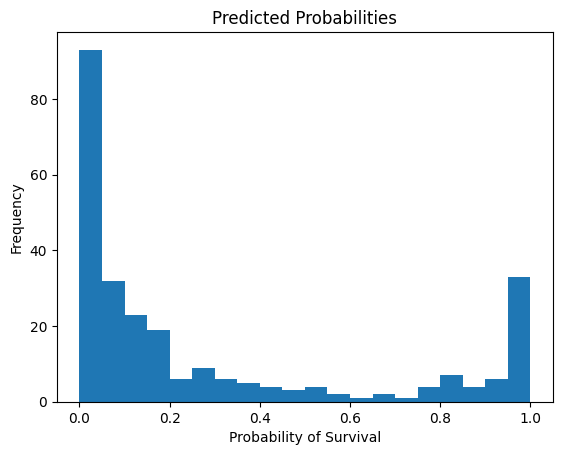

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Get predicted probabilities
y_probs = model.predict(x_eval).flatten()

# Convert to pandas Series for plotting
probs_series = pd.Series(y_probs)

# Plot histogram of predicted probabilities
probs_series.plot(kind='hist', bins=20, title='Predicted Probabilities')
plt.xlabel('Probability of Survival')
plt.show()

### ROC Curve
For analyse the tradeoff between the true positive rate and false positive rate

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


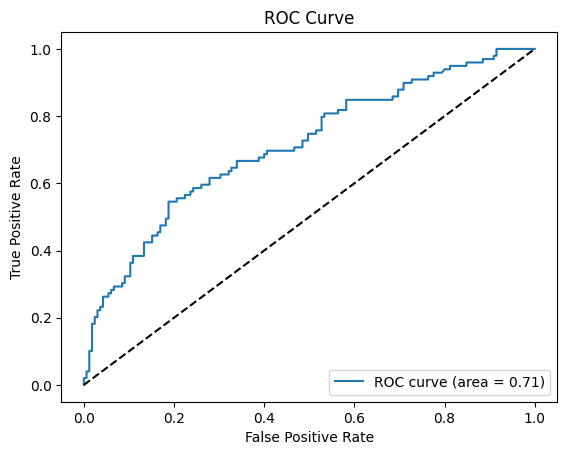

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Predict probabilities
y_probs = model.predict(x_eval).flatten()

# Step 2: Get False Positive Rate, True Positive Rate
fpr, tpr, _ = roc_curve(y_eval, y_probs)

# Step 3: Calculate AUC score
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()